In [3]:
# !pip install fredapi

In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import seaborn.objects as so
import matplotlib.pyplot as plt


from sklearn.preprocessing import StandardScaler, MinMaxScaler, Normalizer

# !pip install pingouin
import pingouin as pg
from statsmodels.tsa.stattools import acf

In [29]:
minerals = pd.read_csv('../Data/commodity_prices.csv',index_col=['Date'])
minerals.index = pd.to_datetime(minerals.index)


In [15]:
## calculate log return from each closing price
minerals_log_return = minerals.filter(regex='Date|Close').copy()
minerals_log_return.iloc[:,1:] = np.log(minerals_log_return.iloc[:,1:].divide(minerals_log_return.iloc[:,1:].shift(1)))
minerals_log_return.columns = [x.replace(' Close','') + '_log_return' if x != 'Date' else x for x in minerals_log_return.columns.to_list()]

minerals_log_return.set_index('Date',inplace=True)

## Percent Change at different Window Sizes
### analyze how past prices relate to current prices over different time horizons.

##### FUNCTION TO CREATE LAGGED DATAFRAMES 

In [17]:
def create_transformed_lagged_df(df, columns, lags, transform_func):
    """
    Create transformed lagged features for a DataFrame.
    Make sure unique date is the index
    
    Parameters:
        df (pd.DataFrame): Input DataFrame with time series data.
        columns (list): List of column names to transform.
        lags (iterable): List or range of lags to apply.
        transform_func (function): Function to apply for lagging (e.g., shift, pct_change).
    
    Returns:
        pd.DataFrame: Transformed lagged features.
    """
    lagged_dfs = []
    for lag in lags:
        transformed_df = transform_func(df[columns], lag)
        transformed_df = transformed_df.add_suffix(f'_lag_{lag}')
        lagged_dfs.append(transformed_df)
    
    return pd.concat(lagged_dfs, axis=1)


##### FUNCTION TO CALCULATE CROSS CORRELATIONS ####

In [18]:

from itertools import combinations

def cross_correlations(df1, df2):
    """
    Compute cross-correlation for all columns in two dataframes.
    If df1 and df2 are the same, only unique column combinations are considered.

    Parameters:
        df1 (pd.DataFrame): First dataframe.
        df2 (pd.DataFrame): Second dataframe.

    Returns:
        Dictionary: Cross-correlation values for unique column combinations.
    """

    correlation_results = {}

    # If df1 and df2 are the same, use only unique column combinations
    if df1.equals(df2):
        column_pairs = combinations(df1.columns, 2)  
    else:
        column_pairs = [(col1, col2) for col1 in df1.columns for col2 in df2.columns]

    for col1, col2 in column_pairs:
        df1_series = df1[col1].dropna()
        df2_series = df2[col2].dropna()

        # Align by index
        aligned_data = pd.concat([df1_series, df2_series], axis=1).dropna()
        df1_series = aligned_data[col1]
        df2_series = aligned_data[col2]

        # Compute correlation
        cross_correlation = np.corrcoef(df1_series, df2_series)[0, 1].round(4)

        # Store results
        correlation_results[f'{col1} vs {col2}'] = cross_correlation

    return correlation_results


### Calculate Cross correlation between each mineral and the lag return of each mineral

In [143]:
lags = range(1,11)
mineral_tickers = ['GC=F Close', 'HG=F Close', 'PA=F Close', 'PL=F Close', 'SI=F Close']

lag_returns_df = create_transformed_lagged_df(
    minerals_vol_returns, 
    mineral_tickers, 
    lags, 
    lambda x, lag: x.pct_change(lag)
)

print(lag_returns_df.shape)
lag_returns_df.head(5)


(1323, 50)


,GC=F Close_lag_1,HG=F Close_lag_1,PA=F Close_lag_1,PL=F Close_lag_1,SI=F Close_lag_1,GC=F Close_lag_2,HG=F Close_lag_2,PA=F Close_lag_2,PL=F Close_lag_2,SI=F Close_lag_2,...,GC=F Close_lag_9,HG=F Close_lag_9,PA=F Close_lag_9,PL=F Close_lag_9,SI=F Close_lag_9,GC=F Close_lag_10,HG=F Close_lag_10,PA=F Close_lag_10,PL=F Close_lag_10,SI=F Close_lag_10
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-03,0.016202,-0.012178,0.014369,0.006029,0.005677,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-06,0.010973,0.000715,0.017336,-0.024479,0.001605,0.027353,-0.011472,0.031954,-0.018598,0.007292,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-07,0.003576,0.001250,0.012416,0.005831,0.012101,0.014588,0.001965,0.029967,-0.018791,0.013726,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-08,-0.009161,0.005350,0.023385,-0.007246,-0.012448,-0.005619,0.006606,0.036091,-0.001458,-0.000497,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
# grab each mineral closing price
df1 = minerals.set_index('Date')[mineral_tickers]
# grab dataframe of lagged returns of each mineral
df2 = lag_returns_df


correlation_results = cross_correlations(df1, df2)
top_corr = sorted(correlation_results.items(), key=lambda x: abs(x[1]), reverse=True)[:20] #top 20 calculations
print('Top Correlations between Mineral Closing Price and Lagged Mineral Return')
for pair, corr in top_corr:
    print(f'{pair}: {corr:.2f}')


Top Correlations between Mineral Closing Price and Lagged Mineral Return
PL=F Close vs PL=F Close_lag_10: 0.26
PL=F Close vs PL=F Close_lag_9: 0.25
PL=F Close vs PL=F Close_lag_8: 0.24
PL=F Close vs PL=F Close_lag_7: 0.23
PL=F Close vs HG=F Close_lag_10: 0.22
PL=F Close vs PL=F Close_lag_6: 0.22
GC=F Close vs GC=F Close_lag_10: 0.22
PL=F Close vs HG=F Close_lag_9: 0.21
PL=F Close vs HG=F Close_lag_8: 0.21
GC=F Close vs GC=F Close_lag_9: 0.20
PL=F Close vs PL=F Close_lag_5: 0.20
PL=F Close vs HG=F Close_lag_7: 0.20
GC=F Close vs GC=F Close_lag_8: 0.19
PL=F Close vs HG=F Close_lag_6: 0.19
PL=F Close vs PL=F Close_lag_4: 0.18
PL=F Close vs PA=F Close_lag_10: 0.18
GC=F Close vs GC=F Close_lag_7: 0.18
PL=F Close vs HG=F Close_lag_5: 0.18
SI=F Close vs HG=F Close_lag_10: 0.18
SI=F Close vs SI=F Close_lag_10: 0.17


##### Correlation between each minearls Daily Returns

In [22]:

df1 = minerals_vol_returns.filter(like='Return')
df2 = minerals_vol_returns.filter(like='Return')
returns_cross_correlations = cross_correlations(df1,df2)

top_cross_correlations = sorted(returns_cross_correlations.items(), key=lambda x: x[1], reverse=True)[:]

print('Top Correlations between Mineral Return and Other Mineral Return')
for pair, corr in top_cross_correlations:
    print(f'{pair}: {corr:.2f}')

Top Correlations between Mineral Return and Other Mineral Return
GC=F Returns vs SI=F Returns: 0.78
PL=F Returns vs SI=F Returns: 0.64
PA=F Returns vs PL=F Returns: 0.58
GC=F Returns vs PL=F Returns: 0.54
PA=F Returns vs SI=F Returns: 0.46
HG=F Returns vs PL=F Returns: 0.46
HG=F Returns vs SI=F Returns: 0.42
GC=F Returns vs PA=F Returns: 0.39
HG=F Returns vs PA=F Returns: 0.38
GC=F Returns vs HG=F Returns: 0.31


##### Correlation between each minearls Lagged Daily Returns

In [23]:
import re
df1 = lag_returns_df
df2 = lag_returns_df

lagged_cross_correlations = cross_correlations(df1,df2)

# only looking at different tickers that are not the same lag - can adjust
filtered_lagged_cross_corr = {
    key: value
    for key, value in lagged_cross_correlations.items()
    if (match := re.findall(r'([\w=]+) Close_lag_(\d+)', key)) and 
       match[0][0] != match[1][0] and  
       int(match[0][1]) != int(match[1][1])  
}
top_lagged_cross_correlations = sorted(filtered_lagged_cross_corr.items(), key=lambda x: x[1], reverse=True)[:20]

print('Top Correlations between Lagged Mineral Return and Lagged Mineral Return')
for pair, corr in top_lagged_cross_correlations:
    print(f'{pair}: {corr:.2f}')

Top Correlations between Lagged Mineral Return and Lagged Mineral Return
SI=F Close_lag_7 vs GC=F Close_lag_8: 0.74
SI=F Close_lag_6 vs GC=F Close_lag_7: 0.74
SI=F Close_lag_8 vs GC=F Close_lag_9: 0.73
SI=F Close_lag_9 vs GC=F Close_lag_10: 0.73
GC=F Close_lag_9 vs SI=F Close_lag_10: 0.72
SI=F Close_lag_5 vs GC=F Close_lag_6: 0.72
GC=F Close_lag_5 vs SI=F Close_lag_6: 0.72
GC=F Close_lag_8 vs SI=F Close_lag_9: 0.72
GC=F Close_lag_6 vs SI=F Close_lag_7: 0.72
GC=F Close_lag_7 vs SI=F Close_lag_8: 0.72
GC=F Close_lag_4 vs SI=F Close_lag_5: 0.71
SI=F Close_lag_4 vs GC=F Close_lag_5: 0.71
SI=F Close_lag_3 vs GC=F Close_lag_4: 0.70
SI=F Close_lag_7 vs GC=F Close_lag_9: 0.69
SI=F Close_lag_8 vs GC=F Close_lag_10: 0.69
SI=F Close_lag_6 vs GC=F Close_lag_8: 0.69
GC=F Close_lag_3 vs SI=F Close_lag_4: 0.68
SI=F Close_lag_9 vs PL=F Close_lag_10: 0.68
GC=F Close_lag_8 vs SI=F Close_lag_10: 0.68
SI=F Close_lag_5 vs GC=F Close_lag_7: 0.67


### All stocks log returns

In [24]:
## calculate log return from each closing price
stock_data_log_return = stock_data.copy()
stock_data_log_return.iloc[:,1:] = np.log(stock_data_log_return.iloc[:,1:].divide(stock_data_log_return.iloc[:,1:].shift(1)))
stock_data_log_return.columns = [x+'_log_return' if x != 'Date' else x for x in stock_data_log_return.columns.to_list()]

stock_data_log_return.set_index('Date',inplace=True)

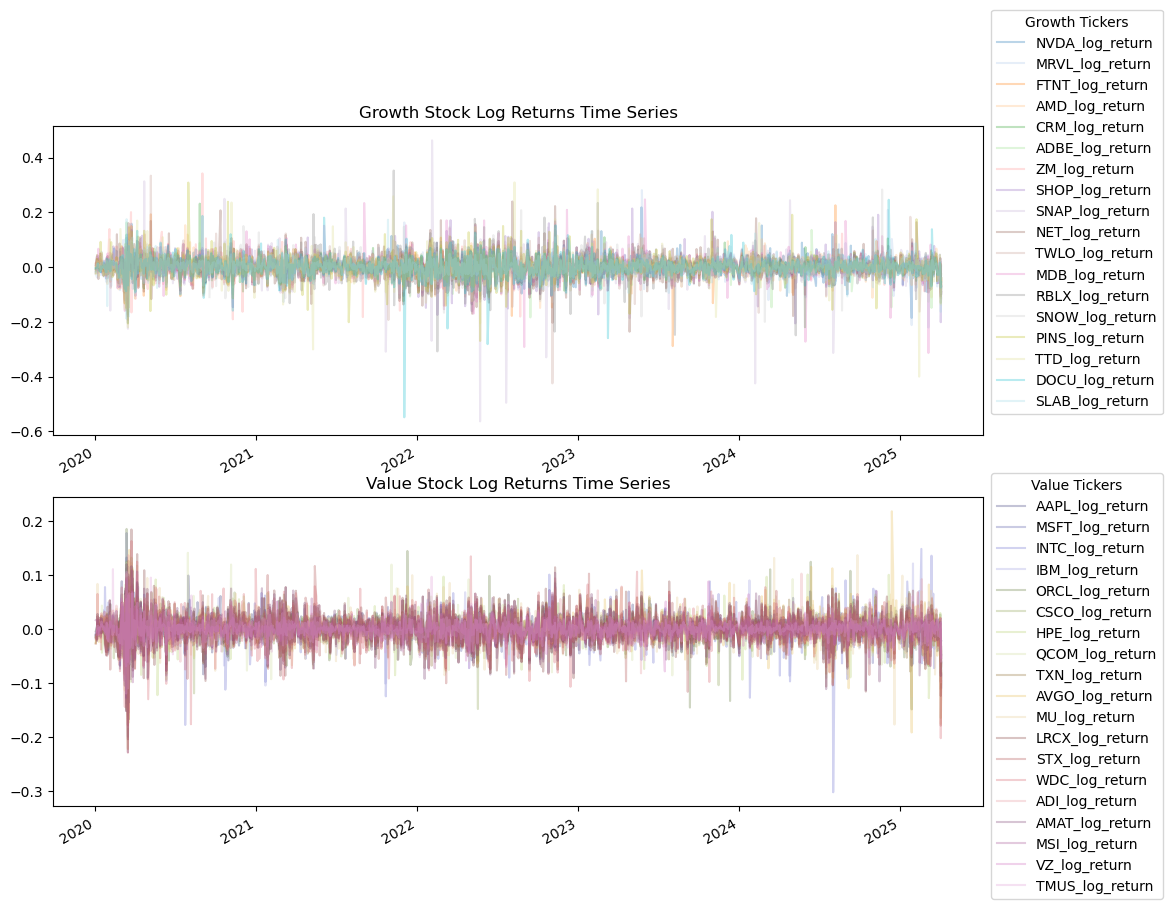

In [25]:
# Plotting the time series for each stock ticker (log returns) in the stock_returns_df

fig,axs = plt.subplots(2,1,figsize=(12,10))

stock_data_log_return.loc[:,[col+"_log_return" for col in growth_stocks]].plot(cmap='tab20',ax=axs[0],alpha=0.3)

stock_data_log_return.loc[:,[col+"_log_return" for col in value_stocks]].plot(cmap='tab20b',ax=axs[1],alpha=0.3)

axs[0].set_title('Growth Stock Log Returns Time Series')
axs[0].legend(title='Growth Tickers',loc='upper right', bbox_to_anchor=(1.2, 1.4))
axs[0].set_xlabel('')

axs[1].set_title('Value Stock Log Returns Time Series')
axs[1].legend(title='Value Tickers',loc='upper right', bbox_to_anchor=(1.2, 1.1))
axs[1].set_xlabel('')


plt.show()

### Lists of different column types
1. Mineral Log Return
2. Mineral Volatility
3. Stock Log Return
4. Stock Volatility

In [26]:
# List of columns for the different groups
minerals_log_return_columns = minerals_log_return.columns.to_list()[1:]
minerals_volatility_columns = minerals_vol_returns.filter(like='Vol').columns.to_list()
stock_log_return_columns = stock_data_log_return.columns.to_list()[1:]
minerals_close_columns = minerals_close.columns[1:].to_list()


### Examine Log Return Trends

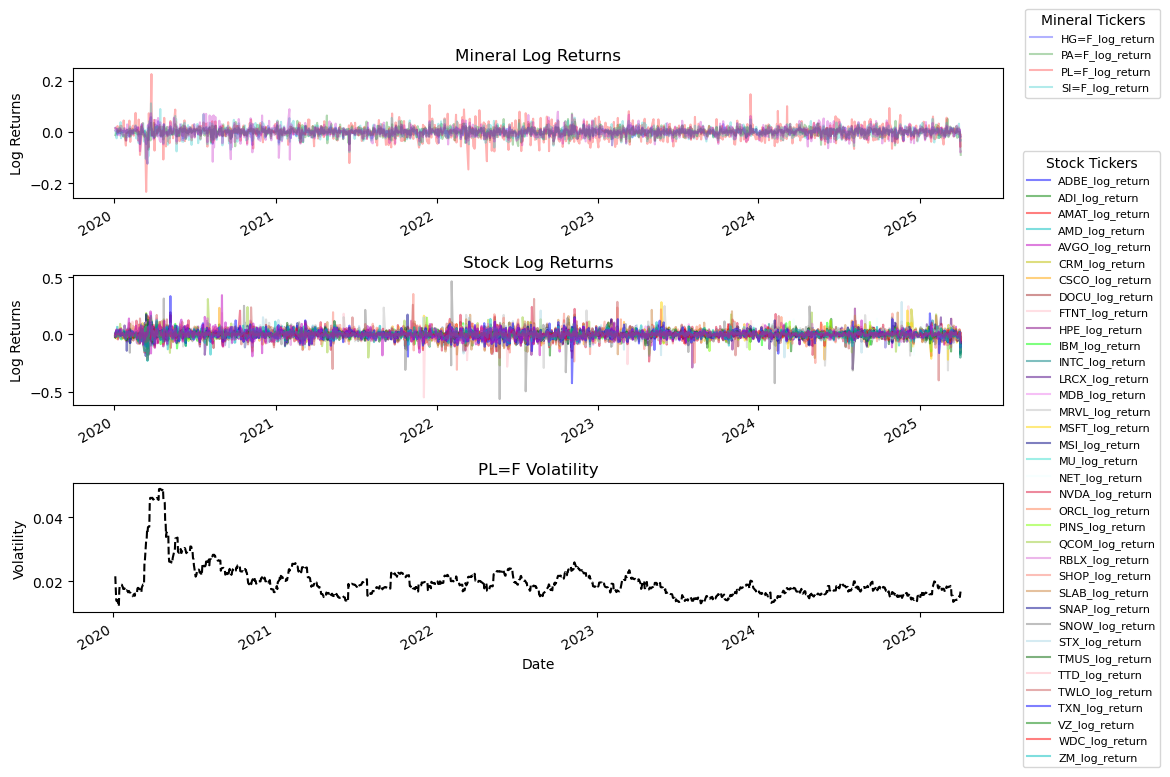

In [27]:
volatility_column = 'PL=F Volatility'

# Plotting the time series for minerals, stocks, and volatility
plt.figure(figsize=(14, 10))

# Plot mineral returns
plt.subplot(3, 1, 1)
minerals_log_return.plot(figsize=(12, 8), ax=plt.gca(), title="Mineral Log Returns",alpha=0.3, color=['b', 'g', 'r', 'c', 'm', 'y'])
plt.legend(minerals_log_return_columns,title='Mineral Tickers', loc='upper right', bbox_to_anchor=(1.175, 1.5),fontsize=8)
plt.ylabel('Log Returns')
plt.xlabel('')

# Plot stock returns
plt.subplot(3, 1, 2)
stock_data_log_return.plot(figsize=(12, 8), ax=plt.gca(),legend=False,alpha=0.5, title="Stock Log Returns",
                               color=['b', 'g', 'r', 'c', 'm', 'y', 'orange', 'brown', 'pink', 'purple', 'lime', 'teal', 'indigo', 'violet',
                                      'silver', 'gold', 'navy', 'turquoise', 'azure', 'crimson', 'coral', 'chartreuse', 'yellowgreen', 'orchid',
                                      'salmon', 'peru', 'darkblue', 'gray', 'lightblue', 'darkgreen', 'lightpink', 'indianred'])
plt.legend(stock_log_return_columns,title='Stock Tickers', loc='upper right', bbox_to_anchor=(1.175, 2),fontsize=8)
plt.ylabel('Log Returns')
plt.xlabel('')

# Plot volatility
plt.subplot(3, 1, 3)
minerals_vol_returns[volatility_column].plot(figsize=(12, 8), ax=plt.gca(), title="PL=F Volatility", color='black', linestyle='--')
plt.ylabel('Volatility')

plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=0.6)

plt.show()


### Examine Log Return Trends from Different Time Periods

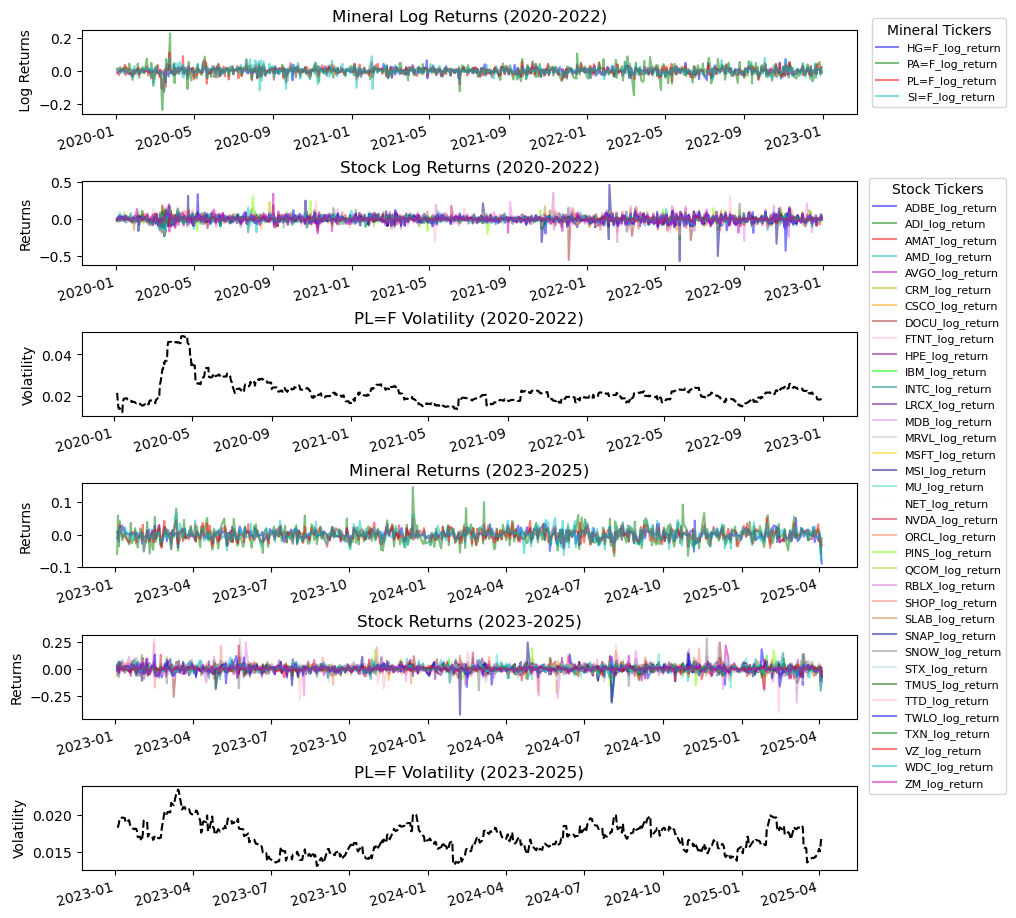

In [28]:

# Define the date ranges
start_date_1 = '2020-01-01'
end_date_1 = '2022-12-31'
start_date_2 = '2023-01-01'
end_date_2 = '2025-12-31'

# Filter data for the two periods
minerals_df_2020_2022 = minerals_log_return.loc[start_date_1:end_date_1].copy()
minerals_df_2023_2025 = minerals_log_return.loc[start_date_2:end_date_2].copy()

stock_df_2020_2022 = stock_data_log_return.loc[start_date_1:end_date_1].copy()
stock_df_2023_2025 = stock_data_log_return.loc[start_date_2:end_date_2].copy()

volatility_df_2020_2022 = minerals_vol_returns.filter(regex='Vol').loc[start_date_1:end_date_1].copy()
volatility_df_2023_2025 = minerals_vol_returns.filter(regex='Vol').loc[start_date_2:end_date_2].copy()

volatility_column = "PL=F Volatility"

# Plotting the time series for minerals, stocks, and volatility for 2020-2022
colors=['b', 'g', 'r', 'c', 'm', 'y', 'orange', 'brown', 'pink', 'purple', 'lime', 'teal', 'indigo', 'violet', 'silver', 'gold', 'navy', 'turquoise', 'azure', 'crimson', 'coral', 'chartreuse', 'yellowgreen', 'orchid', 'salmon', 'peru', 'darkblue', 'gray', 'lightblue', 'darkgreen', 'lightpink']

# fig, axs = plt.subplots()
# plt.figure(figsize=(18, 7))

# Plot mineral returns (2020-2022)
axs1 = plt.subplot(6, 1, 1)
minerals_df_2020_2022[minerals_log_return_columns].plot(figsize=(10, 7), ax=axs1, title="Mineral Log Returns (2020-2022)", color=['b', 'g', 'r', 'c', 'm'],alpha=0.5)
plt.legend(minerals_log_return_columns,title='Mineral Tickers', loc='upper right', bbox_to_anchor=(1.2, 1.2),fontsize=8)
plt.xlabel('')
plt.ylabel(' Log Returns')
axs1.tick_params(axis='x', rotation=15)


# Plot stock returns (2020-2022)
axs2 = plt.subplot(6, 1, 2)
stock_df_2020_2022 [stock_log_return_columns].plot(figsize=(10, 7), ax=axs2, title="Stock Log Returns (2020-2022)", color=colors,alpha=0.5)
plt.legend(stock_log_return_columns,title='Stock Tickers', loc='upper right', bbox_to_anchor=(1.2, 1.1),fontsize=8)
plt.xlabel('')
plt.ylabel('Returns')
axs2.tick_params(axis='x', rotation=15)

# Plot volatility (2020-2022)
axs3 = plt.subplot(6, 1, 3)
volatility_df_2020_2022[volatility_column].plot(figsize=(10, 7), ax=axs3, title="PL=F Volatility (2020-2022)", color='black', linestyle='--')
plt.xlabel('')
plt.ylabel('Volatility')
axs3.tick_params(axis='x', rotation=15)

# Plotting the time series for minerals, stocks, and volatility for 2023-2025
# Plot mineral returns (2023-2025)
axs4 = plt.subplot(6, 1, 4)
minerals_df_2023_2025[minerals_log_return_columns].plot(figsize=(10, 7), ax=axs4, title="Mineral Returns (2023-2025)", color=['b', 'g', 'r', 'c', 'm', 'y'],legend=False,alpha=0.5)
plt.xlabel('')
plt.ylabel('Returns')
axs4.tick_params(axis='x', rotation=15)

# Plot stock returns (2023-2025)
axs5 = plt.subplot(6, 1, 5)
stock_df_2023_2025[stock_log_return_columns].plot(figsize=(10, 7), ax=axs5, title="Stock Returns (2023-2025)",color=colors,legend=False,alpha=0.5)
plt.xlabel('')
plt.ylabel('Returns')
axs5.tick_params(axis='x', rotation=15)

# Plot volatility (2023-2025)
axs6=plt.subplot(6, 1, 6)
volatility_df_2023_2025[volatility_column].plot(figsize=(10, 7), ax=axs6, title="PL=F Volatility (2023-2025)", color='black', linestyle='--',legend=False)
plt.ylabel('Volatility')
plt.xlabel('')
axs6.tick_params(axis='x', rotation=15)

plt.subplots_adjust(left=None, right=None, 
                    top=1.7, bottom=.5, 
                    wspace=0.4, hspace=0.8)

plt.show()


In [29]:

# Create lagged columns for the minerals
lagged_minerals_df = create_transformed_lagged_df(minerals_log_return, minerals_log_return_columns, lags,lambda x, lag: x.shift(lag))
lagged_stock_df = create_transformed_lagged_df(stock_data_log_return, stock_log_return_columns, lags,lambda x, lag: x.shift(lag))

In [30]:
stock_lag_min_corr = pd.concat([lagged_minerals_df.tail(21),stock_data.tail(21).set_index('Date').pct_change()],axis=1).corr()


mineral_ticker_names = ['GC=F', 'HG=F', 'PA=F', 'PL=F','SI=F'] 
chosen_stock_names = np.unique([x.split('_')[0] for x in lagged_stock_df.columns])

result= {}
for mineral in mineral_ticker_names:
    for stock in chosen_stock_names:
        highest_lag = stock_lag_min_corr.filter(like=mineral).loc[[stock],:].max().sort_values(ascending=False).index
        if len(highest_lag) > 0:
            highest_lag = highest_lag[0]
        corr_value = stock_lag_min_corr.filter(like=mineral).loc[[stock],:].max().sort_values(ascending=False).values[:].round(4)
        if len(corr_value) > 0:
            corr_value = corr_value[0]
        result[stock] = (highest_lag,corr_value)
top = pd.DataFrame(result).T.rename(columns={0:'mineral_lag',1:'corr'}).sort_values(by='corr',ascending=False)

result= {}
for mineral in mineral_ticker_names:
    for stock in chosen_stock_names:
        highest_lag = stock_lag_min_corr.filter(like=mineral).loc[[stock],:].max().sort_values(ascending=True).index
        if len(highest_lag) > 0:
            highest_lag = highest_lag[0]
        corr_value = stock_lag_min_corr.filter(like=mineral).loc[[stock],:].max().sort_values(ascending=True).values[:].round(4)
        if len(corr_value) > 0:
            corr_value = corr_value[0]
        result[stock] = (highest_lag,corr_value)

bottom = pd.DataFrame(result).T.rename(columns={0:'mineral_lag',1:'corr'}).sort_values(by='corr',ascending=True)

print(top.head(20))
print('_______________________')

print(bottom.head(20))


                 mineral_lag    corr
MSI    SI=F_log_return_lag_1  0.7812
TMUS   SI=F_log_return_lag_1  0.5979
FTNT   SI=F_log_return_lag_9  0.5823
MDB    SI=F_log_return_lag_4  0.5574
VZ     SI=F_log_return_lag_1  0.5283
ZM     SI=F_log_return_lag_1  0.5014
CSCO   SI=F_log_return_lag_9  0.4887
ADI    SI=F_log_return_lag_9  0.4834
INTC   SI=F_log_return_lag_1  0.4812
ADBE   SI=F_log_return_lag_9  0.4787
TWLO   SI=F_log_return_lag_9  0.4786
IBM    SI=F_log_return_lag_1  0.4775
RBLX   SI=F_log_return_lag_1  0.4728
DOCU   SI=F_log_return_lag_9  0.4703
MRVL   SI=F_log_return_lag_4  0.4637
AVGO   SI=F_log_return_lag_4  0.4488
AMD    SI=F_log_return_lag_4  0.4419
HPE    SI=F_log_return_lag_9  0.4383
QCOM   SI=F_log_return_lag_9  0.4302
TTD   SI=F_log_return_lag_10  0.4167
_______________________
                mineral_lag    corr
TMUS  SI=F_log_return_lag_6  -0.576
VZ    SI=F_log_return_lag_6 -0.4862
CSCO  SI=F_log_return_lag_5 -0.4027
RBLX  SI=F_log_return_lag_2  -0.396
NVDA  SI=F_log_retu

In [71]:
from scipy.stats import linregress
from itertools import product

In [148]:
lags = range(1,11)
mineral_tickers = ['GC=F Close', 'HG=F Close', 'PA=F Close', 'PL=F Close', 'SI=F Close']

lag_returns_df = create_transformed_lagged_df(
    minerals_vol_returns, 
    mineral_tickers, 
    lags, 
    lambda x, lag: np.log(x).diff(lag).dropna()
)

In [149]:
print(lag_returns_df.shape)
lag_returns_df.head(5)

(1322, 50)


,GC=F Close_lag_1,HG=F Close_lag_1,PA=F Close_lag_1,PL=F Close_lag_1,SI=F Close_lag_1,GC=F Close_lag_2,HG=F Close_lag_2,PA=F Close_lag_2,PL=F Close_lag_2,SI=F Close_lag_2,...,GC=F Close_lag_9,HG=F Close_lag_9,PA=F Close_lag_9,PL=F Close_lag_9,SI=F Close_lag_9,GC=F Close_lag_10,HG=F Close_lag_10,PA=F Close_lag_10,PL=F Close_lag_10,SI=F Close_lag_10
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-03,0.016072,-0.012253,0.014266,0.006011,0.005661,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-06,0.010914,0.000714,0.017187,-0.024784,0.001604,0.026986,-0.011538,0.031454,-0.018773,0.007265,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-07,0.003569,0.001249,0.012339,0.005814,0.012029,0.014483,0.001963,0.029527,-0.018970,0.013633,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-08,-0.009204,0.005335,0.023116,-0.007273,-0.012526,-0.005634,0.006584,0.035455,-0.001459,-0.000497,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-09,-0.003667,-0.003020,-0.000485,0.008411,-0.012685,-0.012870,0.002315,0.022631,0.001138,-0.025211,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
def create_transformed_lagged_df(df, columns, lags, transform_func):
    """
    Create transformed lagged features for a DataFrame.
    Make sure unique date is the index
    
    Parameters:
        df (pd.DataFrame): Input DataFrame with time series data.
        columns (list): List of column names to transform.
        lags (iterable): List or range of lags to apply.
        transform_func (function): Function to apply for lagging (e.g., shift, pct_change).
    
    Returns:
        pd.DataFrame: Transformed lagged features.
    """
    lagged_dfs = []
    for lag in lags:
        transformed_df = transform_func(df[columns], lag)
        transformed_df = transformed_df.add_suffix(f'_lag_{lag}')
        lagged_dfs.append(transformed_df)
    
    return pd.concat(lagged_dfs, axis=1)

In [243]:
def generate_pairs(commodities, stocks):
    """
    Create list of all possible (commodity, stock) pairs.
    
    Parameters:
        commodities: Input Dataframe of commodity closing prices with datetime index
        stocks: Input Dataframe of commodity closing prices with datetime index
    
    Returns:
        list: list of tuples of (commodity name, stock name)
    """
    return list(product(commodities.columns, stocks.columns))

def compute_features(commodity, stock, lag=1):
    """
    Operations:
        1. Calculates a lagged log returns of a commodity
        2. Calculates a log return of stock
        3. Calculates a 21-day rolling correlation between the commodity and the stock
        4. Calculates a 3-day gradient of the commodity.
    
    Parameters:
        commodity: Input Dataframe of commodity closing prices with datetime index
        stock: Input Dataframe of commodity closing prices with datetime index
        lag: Integer lag number
    
    Returns:
        pd.DataFrame: dataframe with stock, commodity log returns, rolling_corr, and 3-day gradient
    """
    commodity_name = commodity.name + f'_lag_{str(lag)}'
    stock_name = stock.name
    
    commodity_returns =  np.log(commodity).diff(lag)
    stock_returns = np.log(stock).diff(1)
    df = pd.DataFrame(
        {commodity_name: commodity_returns,
         stock_name: stock_returns
    }).dropna()
    df['rolling_corr'] = df[commodity_name].rolling(window=21).corr(df[stock_name])
    df['gradient'] = df[commodity_name].rolling(window=3).apply(lambda x: linregress(range(3), x).slope, raw=True)

    return df.dropna()

def detect_trade_signals(df, threshold=0.95, min_streak=3):
    """
    Operations:
        1. Identifies rolling correlation over a threshold.
        2. Identifies streaks of rolling correlations over threshold.
        3. Filters for top 50% absolute gradient values.
        4. Calucluates trade signals based on sign of the gradient.
    
    Parameters:
        df: Input Dataframe of commodity closing prices with datetime index
        thershold: int - threshold of rolling correlation
        min_streak: int - minimum number of consecutive days of correlations above threshold
    
    Returns:
        pd.DataFrame: dataframe with rolling_corr, gradient, and trade_signal
    """

    df['over_thresh'] = df['rolling_corr'] > threshold
    df['streak'] = df['over_thresh'].astype(int).groupby(df['over_thresh'].ne(df['over_thresh'].shift()).cumsum()).cumsum()

    # Filter for streaks that meet min_streak requirement
    signal_df = df[(df['streak'] >= min_streak)]

    # Select top 50% of absolute gradient values
    cutoff = signal_df['gradient'].abs().quantile(0.5)
    signal_df = signal_df[signal_df['gradient'].abs() >= cutoff]
    signal_df['trade_signal'] = signal_df['gradient'].apply(lambda x: 'long' if x > 0 else 'short')

    return signal_df


def print_signals(signals, commodity_name, stock_name, lag):
    """Prints trade signals in a readable format."""
    if not signals.empty:
        print(f"\n📢 Trade Signals for {commodity_name} (lag={lag}) & {stock_name}")
        print(signals[['rolling_corr', 'gradient', 'trade_signal']])

def main(commodities, stocks, threshold=0.95, min_streak=3, lag=1):
    """
        
    """

    # Generate pairs
    pairs = generate_pairs(commodities, stocks)

    # Process each pair
    for commodity, stock in pairs:
        # print(f"\n🔄 Processing {commodity} & {stock}...")
        df_features = compute_features(commodities[commodity], stocks[stock], lag=lag)
        trade_signals = detect_trade_signals(df_features, threshold=threshold, min_streak=min_streak)
        
        print_signals(trade_signals, commodity + f"_lag_{lag}", stock, lag=lag)


In [244]:
##### Set Dataframes & Call Function ######
test_commodities = minerals_close.set_index('Date')
test_stocks = stock_data.set_index('Date')

for lag in range(1, 4):
    print(f"\n🚀 Running strategy with LAG = {lag}")
    main(test_commodities, test_stocks, threshold=0.80, min_streak=3, lag=lag)


🚀 Running strategy with LAG = 1

📢 Trade Signals for HG=F Close_lag_1 (lag=1) & ADI
            rolling_corr  gradient trade_signal
Date                                           
2020-05-20       0.80947 -0.005991        short

📢 Trade Signals for HG=F Close_lag_1 (lag=1) & AVGO
            rolling_corr  gradient trade_signal
Date                                           
2020-05-12      0.836060 -0.009331        short
2020-05-18      0.840997  0.014665         long
2020-05-19      0.825615  0.007464         long
2020-05-20      0.800929 -0.005991        short

📢 Trade Signals for HG=F Close_lag_1 (lag=1) & MU
            rolling_corr  gradient trade_signal
Date                                           
2021-11-26      0.850526 -0.023373        short
2021-11-30      0.856298  0.013350         long
2021-12-01      0.846507 -0.010017        short

📢 Trade Signals for HG=F Close_lag_1 (lag=1) & ORCL
            rolling_corr  gradient trade_signal
Date                                  

In [269]:
df = compute_features(test_commodities['HG=F Close'],test_stocks['SNAP'],lag=1)
df = detect_trade_signals(df, threshold=0.7, min_streak=2)

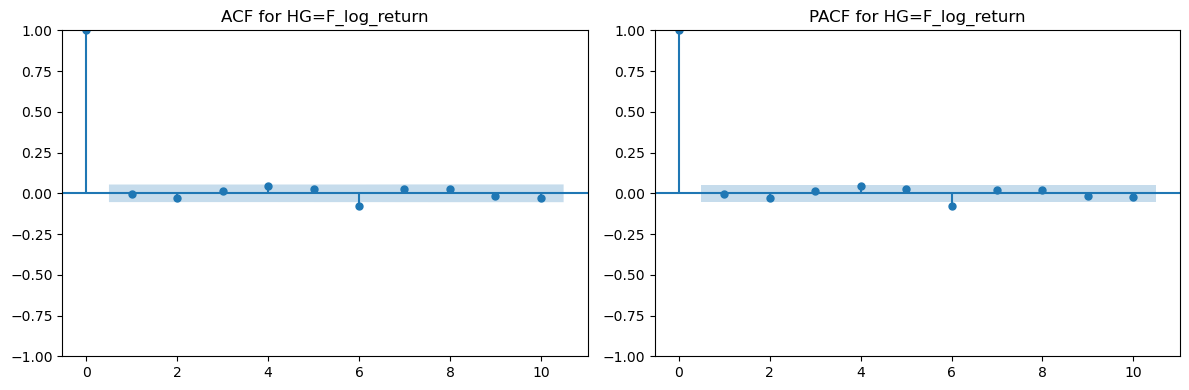

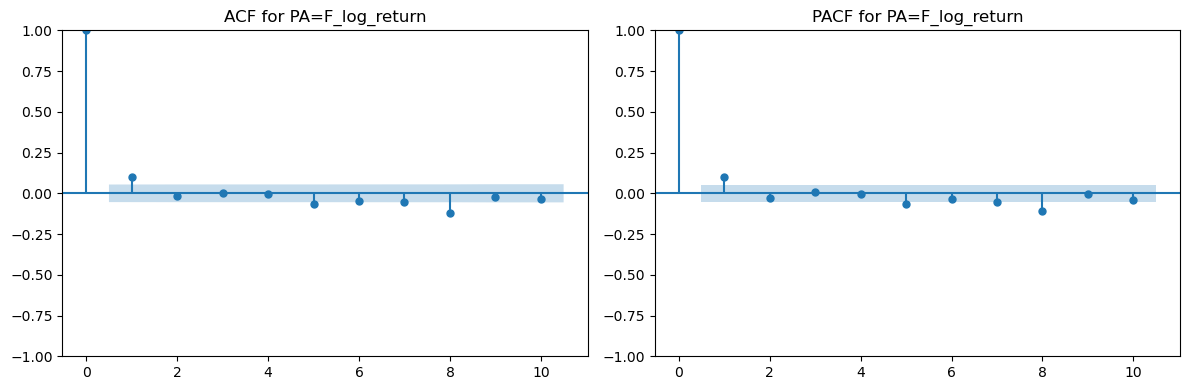

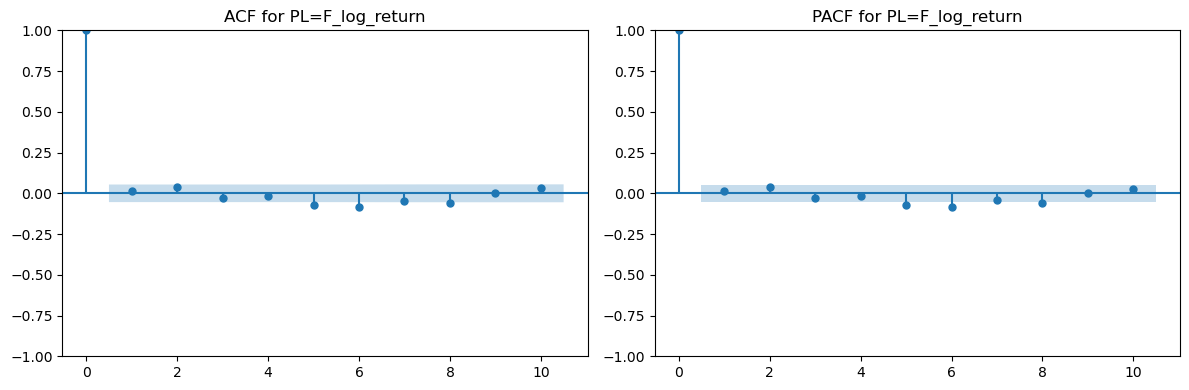

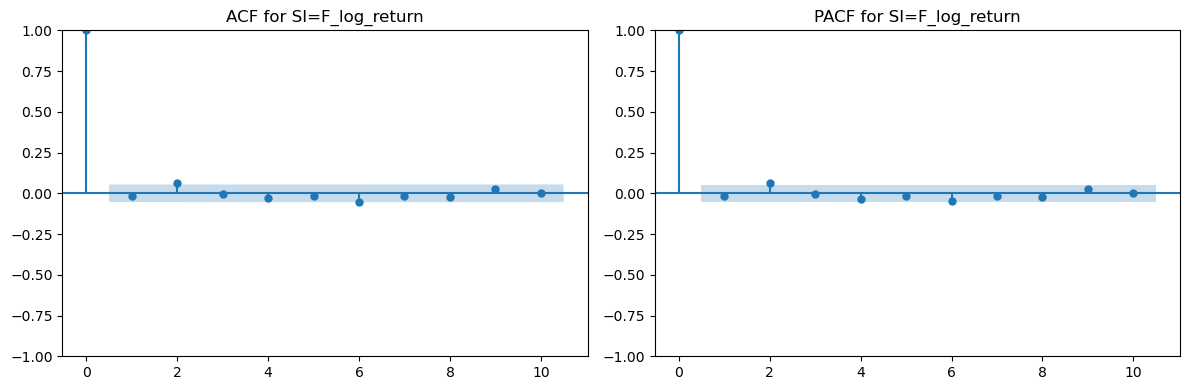

In [35]:
# Loop through each mineral column and plot ACF/PACF directly
for mineral in minerals_log_return_columns:
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))
    
    sm.graphics.tsa.plot_acf(minerals_log_return[mineral].dropna(), lags=10, ax=axs[0])
    axs[0].set_title(f'ACF for {mineral}')
    
    sm.graphics.tsa.plot_pacf(minerals_log_return[mineral].dropna(), lags=10, ax=axs[1])
    axs[1].set_title(f'PACF for {mineral}')
    
    plt.tight_layout()
    plt.show()


### Top correlations between mineral lagged log returns and stock log Return

In [36]:
lag_log_mineral_log_stock_corr = cross_correlations(lagged_minerals_df,stock_data_log_return)
sorted(lag_log_mineral_log_stock_corr.items(), key=lambda x: abs(x[1]), reverse=True)[:20]

[('PL=F_log_return_lag_2 vs TMUS_log_return', 0.1339),
 ('PL=F_log_return_lag_2 vs PINS_log_return', 0.114),
 ('PL=F_log_return_lag_4 vs FTNT_log_return', -0.1087),
 ('PL=F_log_return_lag_9 vs INTC_log_return', 0.1083),
 ('PL=F_log_return_lag_2 vs MSI_log_return', 0.106),
 ('PL=F_log_return_lag_2 vs VZ_log_return', 0.1025),
 ('PL=F_log_return_lag_2 vs LRCX_log_return', 0.1019),
 ('PL=F_log_return_lag_2 vs AMD_log_return', 0.0979),
 ('PL=F_log_return_lag_2 vs ADI_log_return', 0.096),
 ('PL=F_log_return_lag_2 vs AMAT_log_return', 0.0951),
 ('PL=F_log_return_lag_2 vs SNAP_log_return', 0.0936),
 ('PL=F_log_return_lag_6 vs IBM_log_return', -0.093),
 ('PL=F_log_return_lag_2 vs TXN_log_return', 0.0926),
 ('PL=F_log_return_lag_2 vs QCOM_log_return', 0.0923),
 ('PL=F_log_return_lag_2 vs AAPL_log_return', 0.092),
 ('PL=F_log_return_lag_2 vs AVGO_log_return', 0.0918),
 ('PL=F_log_return_lag_2 vs MSFT_log_return', 0.0906),
 ('PA=F_log_return_lag_5 vs TTD_log_return', -0.0906),
 ('PL=F_log_return_l

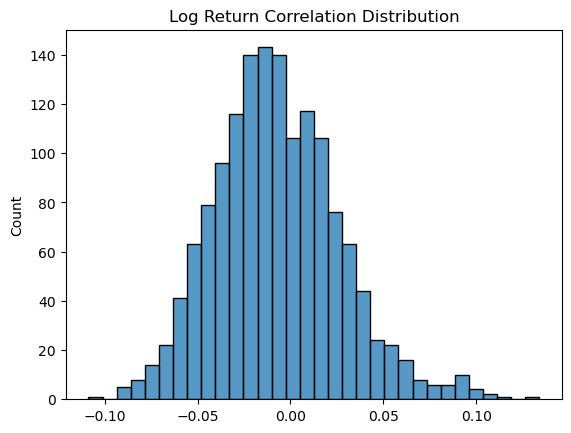

In [37]:
sns.histplot(list(lag_log_mineral_log_stock_corr.values()))
plt.title("Log Return Correlation Distribution")
plt.show()

### Top correlations between mineral lagged log returns and stock lagged log returns

In [38]:
mineral_stock_lag_corr = cross_correlations(lagged_minerals_df,lagged_stock_df)
top_mineral_stock_lag_corr = sorted(mineral_stock_lag_corr.items(), key=lambda x: abs(x[1]), reverse=True)[:20]

top_mineral_stock_lag_corr

[('HG=F_log_return_lag_1 vs WDC_log_return_lag_1', 0.272),
 ('HG=F_log_return_lag_10 vs WDC_log_return_lag_10', 0.2651),
 ('HG=F_log_return_lag_9 vs WDC_log_return_lag_9', 0.265),
 ('HG=F_log_return_lag_8 vs WDC_log_return_lag_8', 0.2639),
 ('HG=F_log_return_lag_6 vs WDC_log_return_lag_6', 0.2638),
 ('HG=F_log_return_lag_7 vs WDC_log_return_lag_7', 0.2636),
 ('HG=F_log_return_lag_5 vs WDC_log_return_lag_5', 0.2635),
 ('HG=F_log_return_lag_4 vs WDC_log_return_lag_4', 0.2628),
 ('HG=F_log_return_lag_2 vs WDC_log_return_lag_2', 0.2627),
 ('HG=F_log_return_lag_3 vs WDC_log_return_lag_3', 0.2624),
 ('PL=F_log_return_lag_1 vs ADI_log_return_lag_1', 0.2565),
 ('PL=F_log_return_lag_1 vs WDC_log_return_lag_1', 0.2557),
 ('PL=F_log_return_lag_3 vs ADI_log_return_lag_3', 0.2539),
 ('PL=F_log_return_lag_2 vs ADI_log_return_lag_2', 0.2534),
 ('PL=F_log_return_lag_7 vs WDC_log_return_lag_7', 0.2533),
 ('PL=F_log_return_lag_10 vs WDC_log_return_lag_10', 0.2533),
 ('PL=F_log_return_lag_3 vs WDC_log_re

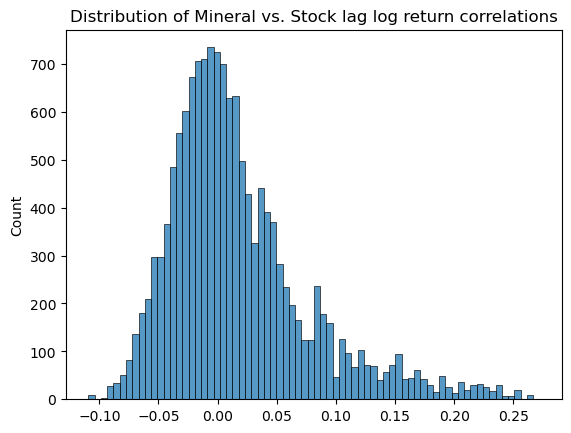

In [39]:
sns.histplot(list(mineral_stock_lag_corr.values()))
plt.title("Distribution of Mineral vs. Stock lag log return correlations")
plt.show()

#### Examine Volume and Volatility

In [40]:
### Create Volume Dataframe
epsilon = 1e-8
mineral_volume = minerals.filter(regex='Date|Volume').set_index('Date').copy() + epsilon
# mineral_VolatilityOfVolume = mineral_volume.pct_change().rolling(window=30,min_periods=1).std()
mineral_VolatilityOfVolume = np.log(mineral_volume).diff().rolling(window=30, min_periods=1).std()

mineral_VolatilityOfClosingPrice = minerals_vol_returns.filter(regex='Volatility').copy()

mineral_vol = pd.concat([mineral_VolatilityOfVolume,mineral_VolatilityOfClosingPrice],axis=1).dropna()

scaler = StandardScaler()

min_vol_scaled = pd.DataFrame(scaler.fit_transform(mineral_vol),columns=mineral_vol.columns,index=mineral_vol.index)

In [41]:
log_returns_volume = np.log(mineral_volume).diff()
log_returns_price = np.log(minerals_close.set_index('Date')).diff()

volatility_volume = log_returns_volume.rolling(window=30, min_periods=1).std()
volatility_price = log_returns_price.rolling(window=30, min_periods=1).std()

vp_vv = pd.concat([volatility_volume,volatility_price],axis=1)

scaler = StandardScaler()

vp_vv_scaled = pd.DataFrame(scaler.fit_transform(vp_vv),columns=vp_vv.columns,index=vp_vv.index)


In [44]:
scaler = MinMaxScaler()
mineral_volume = pd.DataFrame(scaler.fit_transform(mineral_volume),columns=mineral_volume.columns,index=mineral_volume.index)

In [45]:
# Create lagged volume and volatility columns up to 5 lags
lags = range(1, 6)
lagged_volatility_columns = minerals_vol_returns.filter(like='Vola').columns
mineral_volume_columns =  mineral_volume.columns

# Create a DataFrame to hold lagged values
lagged_volume_df =  create_transformed_lagged_df(mineral_volume, mineral_volume_columns, lags,lambda x, lag: x.pct_change(lag))
lagged_volatility_df = create_transformed_lagged_df(minerals_vol_returns, lagged_volatility_columns, lags,lambda x, lag: x.shift(lag))

In [46]:
# Function to calculate ACF and PACF for a single series
def calculate_acf_pacf(x, lags=8):
    x_values = x.values.flatten() 
    lags = int(lags)
    
    # Calculate ACF and PACF using numpy arrays
    acf_vals = acf(x_values, nlags=lags, adjusted=True)  # Only use adjusted (no fft)
    pacf_vals = pacf(x_values, nlags=lags)  # Removed adjusted argument as it is not accepted now
    
    return acf_vals, pacf_vals

# Now calculate ACF and PACF for each interaction term with stock returns
acf_results = {}
pacf_results = {}
